In [2]:
# Important Libraries and Load Data 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import plotly.graph_objects as go
from plotly.subplots import make_subplots


# Load Excel file
df = pd.read_excel('/Users/abhishekprajapati/Desktop/Excel/Pandas Project .xlsx')

# Convert dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])


# Create calculated columns
df["Revenue"] = df["Units Sold"] * df["Unit Price"]

df["Total Cost"] = df["Units Sold"] * df["Unit Cost"]

df["Profit"] = df["Revenue"] - df["Total Cost"]

df["Profit Margin"] = np.where(
    df["Revenue"] != 0,
    (df["Profit"] / df["Revenue"]) * 100,
    0
)

# Month column
df["Month"] = df["Order Date"].dt.to_period("M").astype(str)

print("Data loaded successfully!")
print(df.shape)

Data loaded successfully!
(1000, 16)


In [3]:
# Create KPI's 

# =========================
# KPI CALCULATIONS
# =========================

total_revenue = df["Revenue"].sum()

total_cost = df["Total Cost"].sum()

total_profit = df["Profit"].sum()

total_orders = df["Order ID"].nunique()

total_units = df["Units Sold"].sum()

profit_margin = (
    total_profit / total_revenue
) * 100


print("========== DASHBOARD KPIs ==========")

print(f"Total Revenue : ${total_revenue:,.2f}")

print(f"Total Cost    : ${total_cost:,.2f}")

print(f"Total Profit  : ${total_profit:,.2f}")

print(f"Total Orders  : {total_orders:,}")

print(f"Total Units   : {total_units:,}")

print(f"Profit Margin : {profit_margin:.2f}%")

========== DASHBOARD KPIs ==========
Total Revenue : $1,327,321,840.33
Total Cost    : $936,119,228.77
Total Profit  : $391,202,611.56
Total Orders  : 1,000
Total Units   : 5,053,988
Profit Margin : 29.47%


In [4]:
# Prepare Chart data 

# =========================
# MONTHLY DATA
# =========================

monthly = (
    df.groupby("Month")
      .agg(
          Revenue=("Revenue", "sum"),
          Cost=("Total Cost", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)


# =========================
# ITEM TYPE
# =========================

item_sales = (
    df.groupby("Item Type")["Revenue"]
      .sum()
      .reset_index()
      .sort_values("Revenue", ascending=True)
)


# =========================
# REGION
# =========================

region_sales = (
    df.groupby("Region")["Revenue"]
      .sum()
      .reset_index()
      .sort_values("Revenue", ascending=False)
)


# =========================
# SALES CHANNEL
# =========================

channel_sales = (
    df.groupby("Sales Channel")["Revenue"]
      .sum()
      .reset_index()
)


# =========================
# ORDER PRIORITY
# =========================

priority_sales = (
    df.groupby("Order Priority")["Revenue"]
      .sum()
      .reset_index()
)


# =========================
# TOP 10 COUNTRIES
# =========================

top_countries = (
    df.groupby("Country")["Revenue"]
      .sum()
      .reset_index()
      .sort_values("Revenue", ascending=False)
      .head(10)
      .sort_values("Revenue", ascending=True)
)

In [6]:
# Create Dashboard 

# =========================================================
# CREATE DASHBOARD
# =========================================================

fig = make_subplots(

    rows=3,
    cols=3,

    # Row 1 is reserved for KPI cards
    row_heights=[0.24, 0.38, 0.38],

    specs=[
        [
            {"type": "xy"},
            {"type": "xy"},
            {"type": "xy"}
        ],

        [
            {"type": "xy"},
            {"type": "xy"},
            {"type": "xy"}
        ],

        [
            {"type": "domain"},
            {"type": "xy"},
            {"type": "xy"}
        ]
    ],

    subplot_titles=(
        "", "", "",

        "Revenue, Cost & Profit",
        "Sales by Item Type",
        "Sales by Region",

        "Sales Channel",
        "Top 10 Countries",
        "Revenue vs Cost vs Profit"
    ),

    vertical_spacing=0.08,

    horizontal_spacing=0.07
)

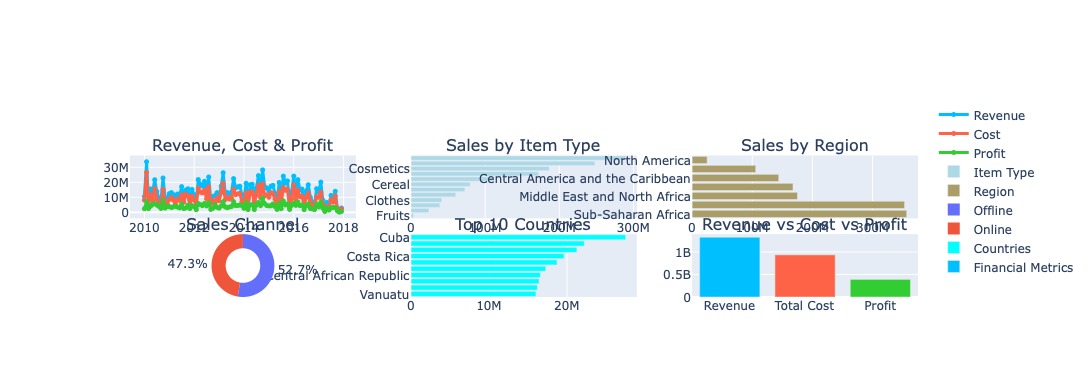

In [7]:
# Add All Graphs

# =========================================================
# 1. REVENUE / COST / PROFIT TREND
# =========================================================

fig.add_trace(

    go.Scatter(
        x=monthly["Month"],
        y=monthly["Revenue"],
        mode="lines+markers",
        name="Revenue",
        line=dict(
            color="deepskyblue",
            width=3
        ),
        marker=dict(
            size=5
        ),
        hovertemplate=
        "<b>Month:</b> %{x}<br>" +
        "<b>Revenue:</b> $%{y:,.0f}" +
        "<extra></extra>"
    ),
    row=2,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=monthly["Month"],
        y=monthly["Cost"],
        mode="lines+markers",
        name="Cost",
        line=dict(
            color="tomato",
            width=3
        ),
        marker=dict(
            size=5
        ),
        hovertemplate=
        "<b>Month:</b> %{x}<br>" +
        "<b>Cost:</b> $%{y:,.0f}" +
        "<extra></extra>"
    ),
    row=2,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=monthly["Month"],
        y=monthly["Profit"],
        mode="lines+markers",
        name="Profit",
        line=dict(
            color="limegreen",
            width=3
        ),
        marker=dict(
            size=5
        ),
        hovertemplate=
        "<b>Month:</b> %{x}<br>" +
        "<b>Profit:</b> $%{y:,.0f}" +
        "<extra></extra>"
    ),
    row=2,
    col=1
)

# =========================================================
# 2. SALES BY ITEM TYPE
# =========================================================

fig.add_trace(
    go.Bar(
        x=item_sales["Revenue"],
        y=item_sales["Item Type"],
        orientation="h",
        name="Item Type",
        marker_color="#ADD8E6",
        hovertemplate=
        "<b>%{y}</b><br>" +
        "Revenue: $%{x:,.0f}" +
        "<extra></extra>"
    ),
    row=2,
    col=2
)

# =========================================================
# 3. SALES BY REGION
# =========================================================

fig.add_trace(
    go.Bar(
        x=region_sales["Revenue"],
        y=region_sales["Region"],
        orientation="h",
        name="Region",
        marker_color="#AA9D68",
        hovertemplate=
        "<b>%{y}</b><br>" +
        "Revenue: $%{x:,.0f}" +
        "<extra></extra>"
    ),
    row=2,
    col=3
)

# =========================================================
# 4. SALES CHANNEL
# =========================================================

fig.add_trace(
    go.Pie(
        labels=channel_sales["Sales Channel"],
        values=channel_sales["Revenue"],
        hole=0.55,
        name="Sales Channel",
        textinfo="percent",
        hovertemplate=
        "<b>%{label}</b><br>" +
        "Revenue: $%{value:,.0f}<br>" +
        "Share: %{percent}" +
        "<extra></extra>"
    ),
    row=3,
    col=1
)

# =========================================================
# 5. TOP 10 COUNTRIES
# =========================================================

fig.add_trace(
    go.Bar(
        x=top_countries["Revenue"],
        y=top_countries["Country"],
        orientation="h",
        name="Countries",
        marker_color="#00FFFF",
        hovertemplate=
        "<b>%{y}</b><br>" +
        "Revenue: $%{x:,.0f}" +
        "<extra></extra>"
    ),
    row=3,
    col=2
)

# =========================================================
# 6. REVENUE VS COST VS PROFIT
# =========================================================

metrics = [
    "Revenue",
    "Total Cost",
    "Profit"
]

metric_values = [
    total_revenue,
    total_cost,
    total_profit
]


fig.add_trace(

    go.Bar(

        x=metrics,

        y=metric_values,

        name="Financial Metrics",

        marker_color=[
            "deepskyblue",
            "tomato",
            "limegreen"
        ],

        hovertemplate=
        "<b>%{x}</b><br>" +
        "$%{y:,.0f}" +
        "<extra></extra>"
    ),

    row=3,
    col=3
)

In [8]:
# Let's Now Add Kpi Card 

# =========================================================
# KPI CARD FUNCTION
# =========================================================

def add_kpi_card(
    x0,
    x1,
    y0,
    y1,
    title,
    value,
    color
):

    # Outer glowing border
    fig.add_shape(

        type="rect",

        xref="paper",
        yref="paper",

        x0=x0,
        x1=x1,

        y0=y0,
        y1=y1,

        line=dict(
            color=color,
            width=2
        ),

        fillcolor="rgba(10,25,45,0.95)",

        layer="above"
    )


    # KPI title
    fig.add_annotation(

        x=(x0 + x1) / 2,

        y=y1 - 0.025,

        xref="paper",
        yref="paper",

        text=f"<b>{title}</b>",

        showarrow=False,

        font=dict(
            size=12,
            color="white"
        )
    )


    # KPI value
    fig.add_annotation(

        x=(x0 + x1) / 2,

        y=y0 + 0.025,

        xref="paper",
        yref="paper",

        text=f"<b>{value}</b>",

        showarrow=False,

        font=dict(
            size=18,
            color=color
        )
    )

# Now Add all ^ kpi cards which we have created    


# =========================================================
# FIRST KPI ROW
# =========================================================

add_kpi_card(
    0.02, 0.31,
    0.88, 0.97,
    "TOTAL REVENUE",
    f"${total_revenue/1e9:.2f}B",
    "deepskyblue"
)


add_kpi_card(
    0.355, 0.645,
    0.88, 0.97,
    "TOTAL COST",
    f"${total_cost/1e9:.2f}B",
    "tomato"
)


add_kpi_card(
    0.69, 0.98,
    0.88, 0.97,
    "TOTAL PROFIT",
    f"${total_profit/1e9:.2f}B",
    "limegreen"
)


# =========================================================
# SECOND KPI ROW
# =========================================================

add_kpi_card(
    0.02, 0.31,
    0.77, 0.86,
    "TOTAL ORDERS",
    f"{total_orders:,}",
    "violet"
)


add_kpi_card(
    0.355, 0.645,
    0.77, 0.86,
    "TOTAL UNITS SOLD",
    f"{total_units/1e6:.2f}M",
    "gold"
)


add_kpi_card(
    0.69, 0.98,
    0.77, 0.86,
    "PROFIT MARGIN",
    f"{profit_margin:.2f}%",
    "cyan"
)

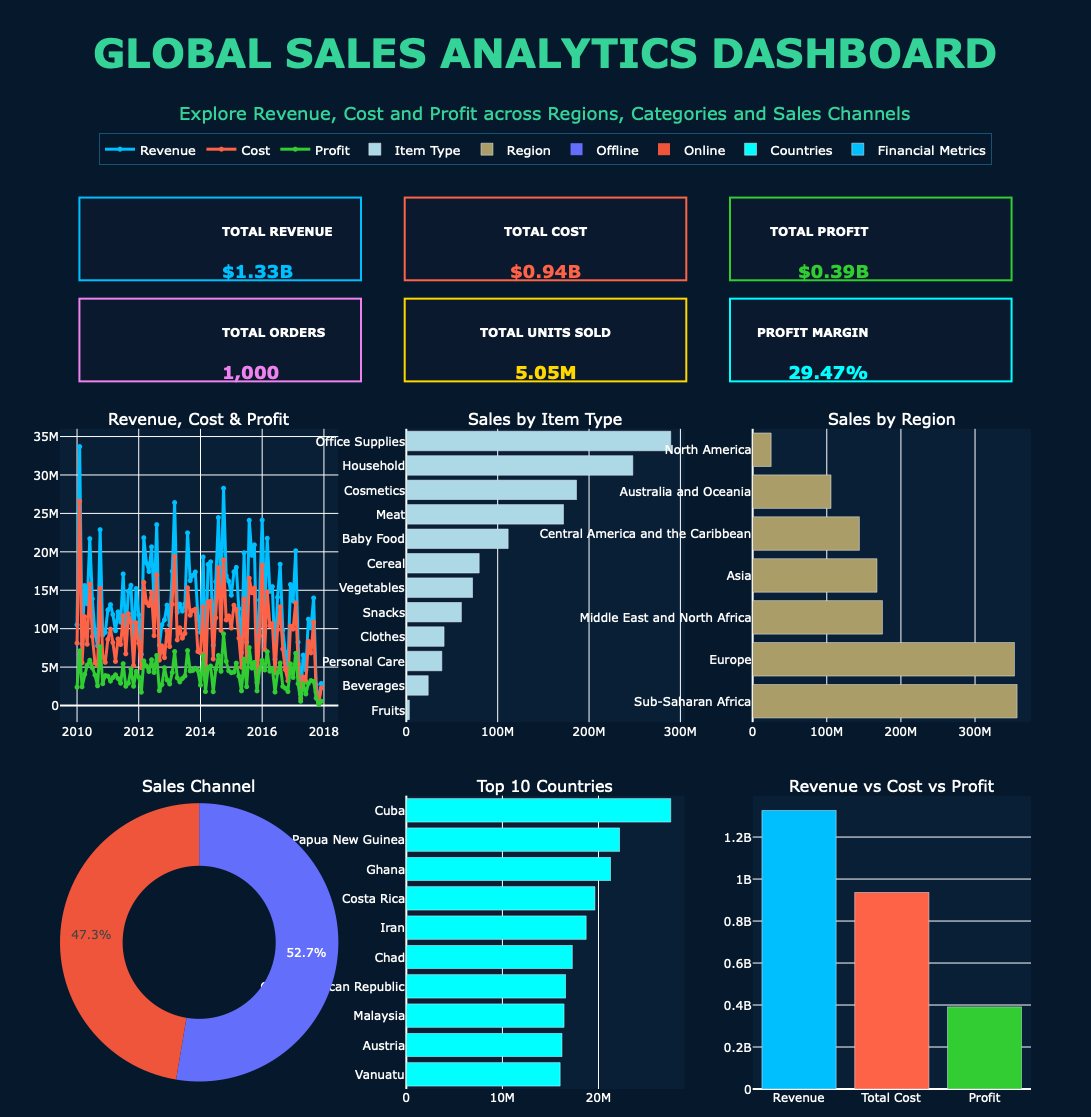

In [9]:
# Style the Dashboard 

fig.update_layout(

    # Dashboard size
    width=1400,
    height=1100,

    # Space for Title + Legend
    margin=dict(
        l=60,
        r=60,
        t=170,
        b=20
    ),

    # =========================
    # MAIN TITLE
    # =========================
    title=dict(
        text="<b>GLOBAL SALES ANALYTICS DASHBOARD</b><br>"
             "<span style='font-size:18px'>"
             "Explore Revenue, Cost and Profit across Regions, Categories and Sales Channels"
             "</span>",

        x=0.5,
        xanchor="center",

        y=0.94,
        yanchor="top",

        font=dict(
            size=40,
            color="#36D399"
        )
    ),

    # =========================
    # HORIZONTAL LEGEND
    # =========================
    legend=dict(
        orientation="h",

        # Below title
        x=0.5,
        y=1.04,

        xanchor="center",
        yanchor="top",

        # Space between legend items
        tracegroupgap=12,

        font=dict(
            size=13,
            color="white"
        ),

        bgcolor="rgba(6,24,43,0.85)",
        bordercolor="rgba(56,189,248,0.35)",
        borderwidth=1
    ),

    # =========================
    # COLORS / BACKGROUND
    # =========================
    paper_bgcolor="#06182B",
    plot_bgcolor="#081F36",

    font=dict(
        color="white"
    ),

    hovermode="closest"
)

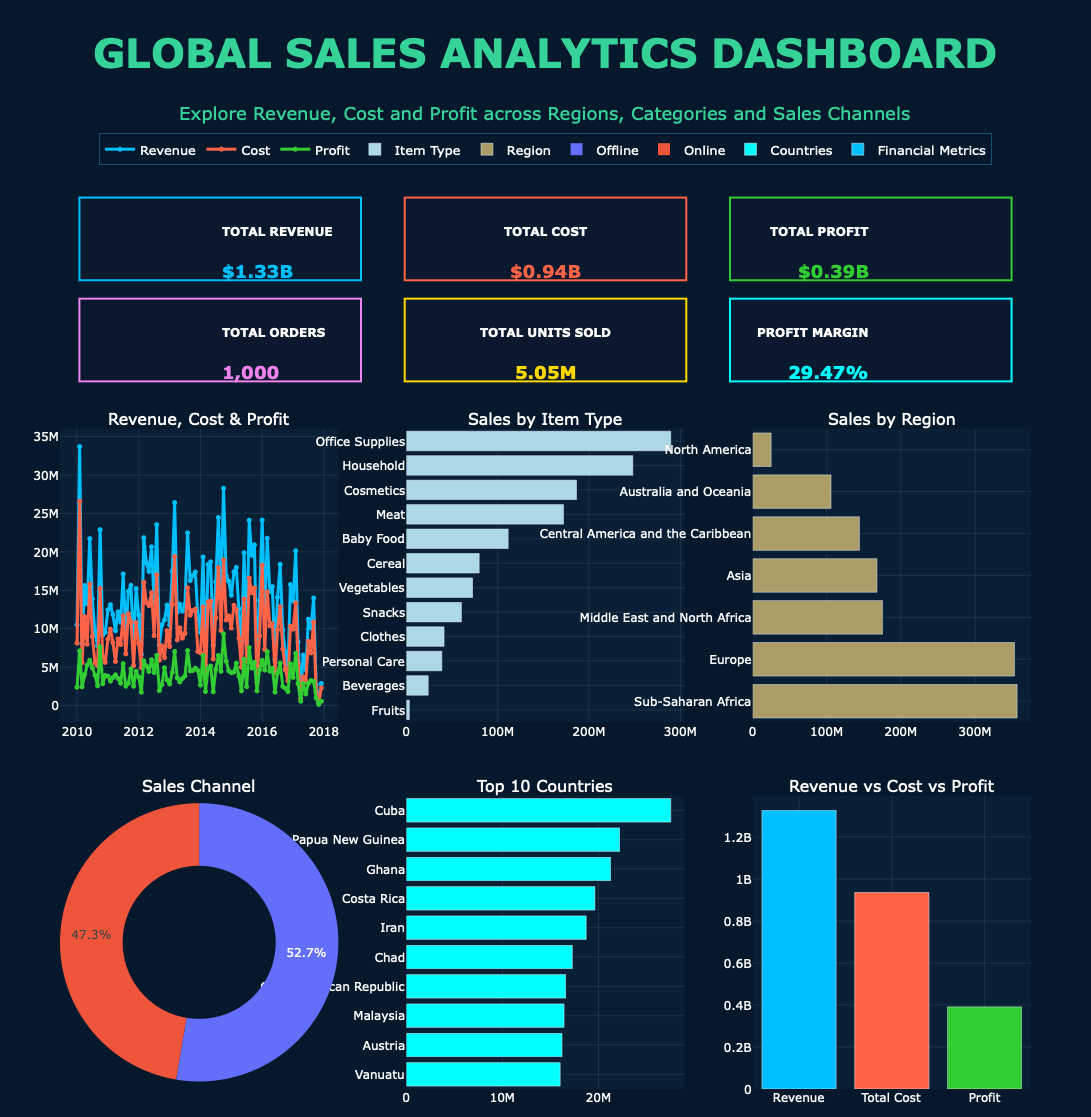

In [10]:
# Now Fix the Axis of the Dashboard 


fig.update_xaxes(

    showgrid=True,

    gridcolor="rgba(255,255,255,0.08)",

    zeroline=False,

    tickfont=dict(
        color="white"
    )
)


fig.update_yaxes(

    showgrid=True,

    gridcolor="rgba(255,255,255,0.08)",

    zeroline=False,

    tickfont=dict(
        color="white"
    )
)

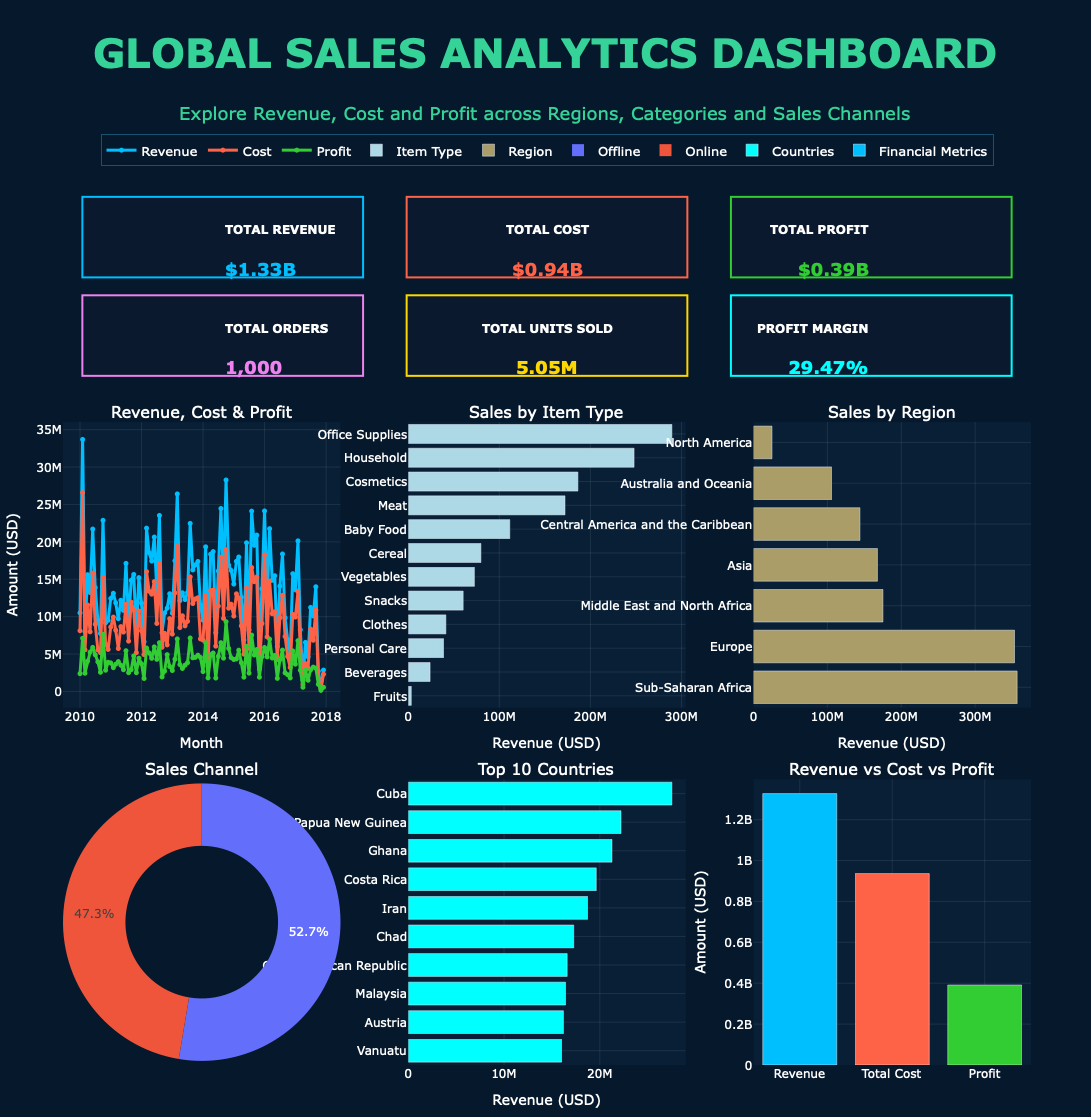

In [11]:
# =========================================================
# IMPROVE CHARTS
# =========================================================

# Revenue trend
fig.update_xaxes(
    title_text="Month",
    row=2,
    col=1
)

fig.update_yaxes(
    title_text="Amount (USD)",
    row=2,
    col=1
)


# Item type
fig.update_xaxes(
    title_text="Revenue (USD)",
    row=2,
    col=2
)


# Region
fig.update_xaxes(
    title_text="Revenue (USD)",
    row=2,
    col=3
)


# Countries
fig.update_xaxes(
    title_text="Revenue (USD)",
    row=3,
    col=2
)


# Financial metrics
fig.update_yaxes(
    title_text="Amount (USD)",
    row=3,
    col=3
)

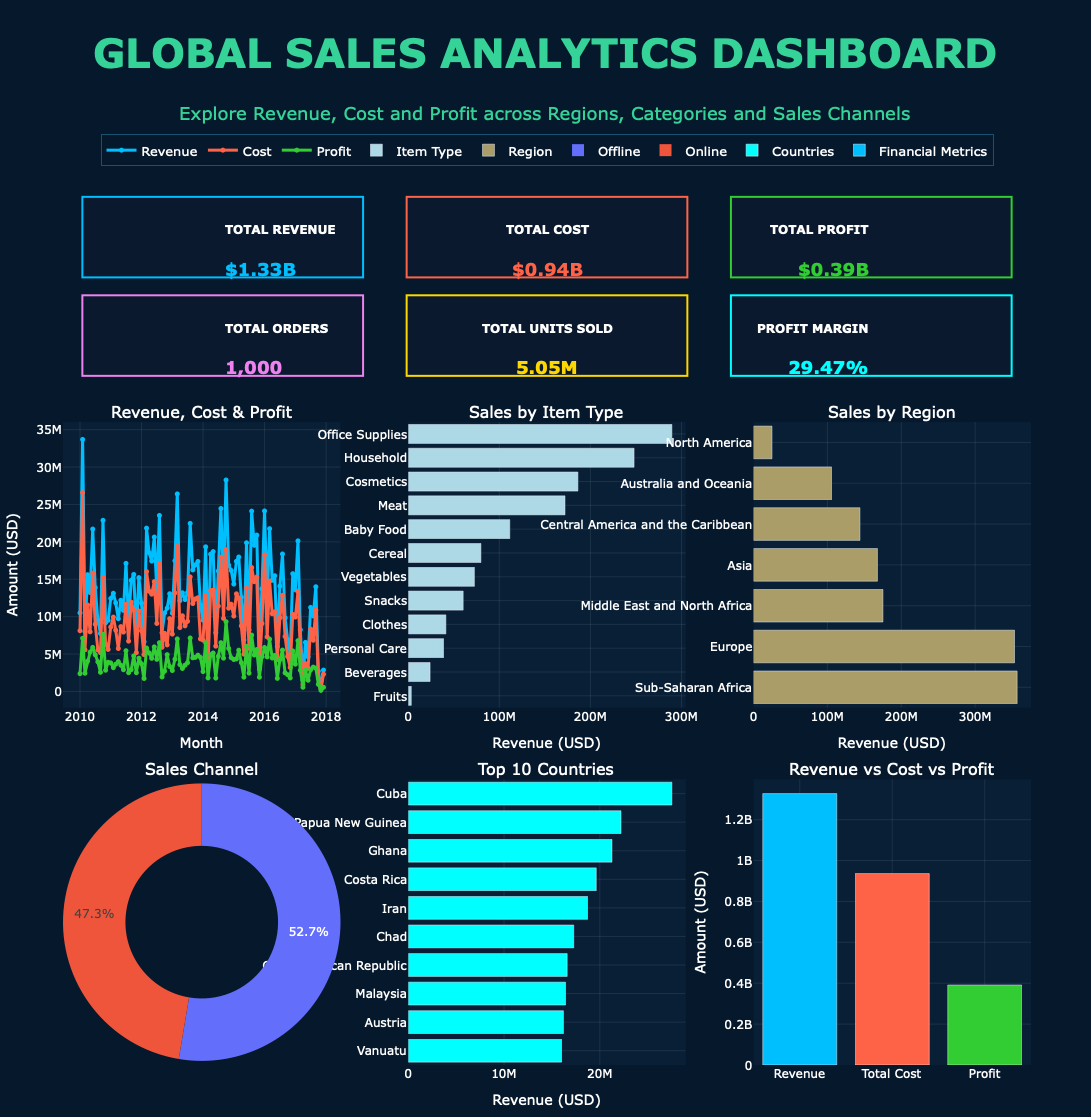

In [12]:
fig.show()